# Crime Pattern Analysis Using K-Means
## Part A: USArrests Dataset


### Objective

The aim of this analysis is to use K-Means clustering to identify groups of US states that have similar crime patterns using the USArrests dataset.

I will first explore and clean the data, select and standardize the crime features, and then use PCA to reduce the dimensions of the data. After that, I will use the elbow method to choose a suitable number of clusters, apply K-Means clustering, visualize the clusters, and interpret the results.

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42


## 2. Load the Data

The USArrests dataset contains crime statistics for the 50 US states. The dataset includes Murder, Assault, and Rape rates per 100,000 residents, together with UrbanPop, which represents the percentage of people living in urban areas.

The dataset also contains a State column that identifies each state.

In [ ]:
df = pd.read_csv("USArrests.csv")
print(df.shape)
df.head()


(50, 5)


,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


## 3. Exploratory Data Analysis (EDA)

Before applying K-Means clustering, I first explore the dataset to understand its structure and the distribution of the crime variables.

In this section, I will check the first few rows, data types, missing values, summary statistics, and relationships between the variables. This will help me understand the data and identify any issues that may need to be handled before clustering.

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
 4   State     50 non-null     str    
dtypes: float64(2), int64(2), str(1)
memory usage: 2.1 KB


In [ ]:
df.describe()


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [ ]:
# Missing values check
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64

Duplicate rows: 0


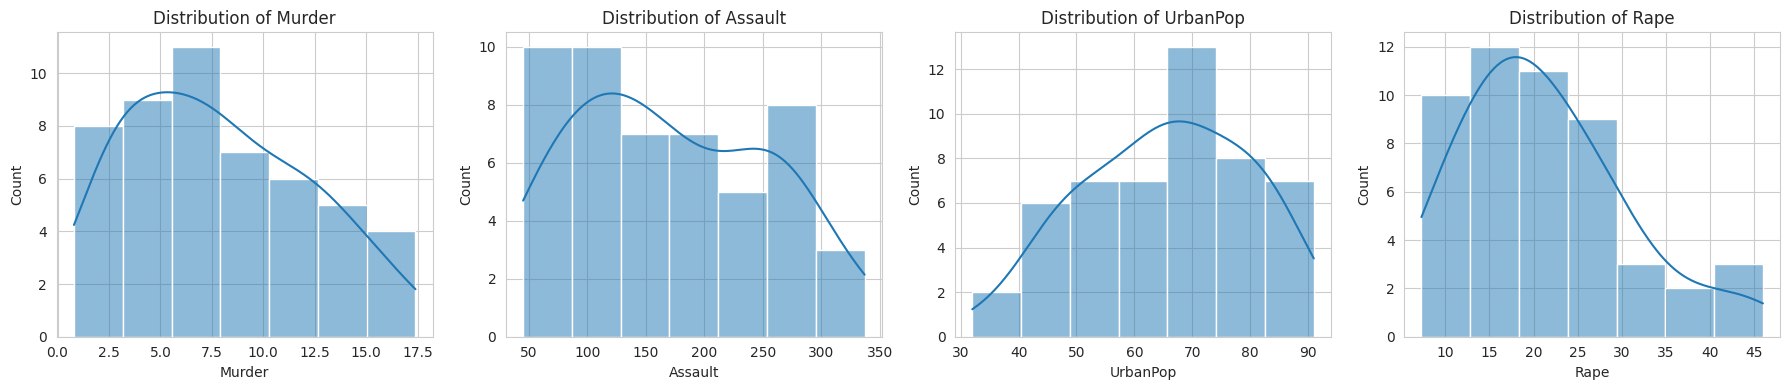

In [ ]:
# Distribution of each numeric feature
numeric_cols = ["Murder", "Assault", "UrbanPop", "Rape"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


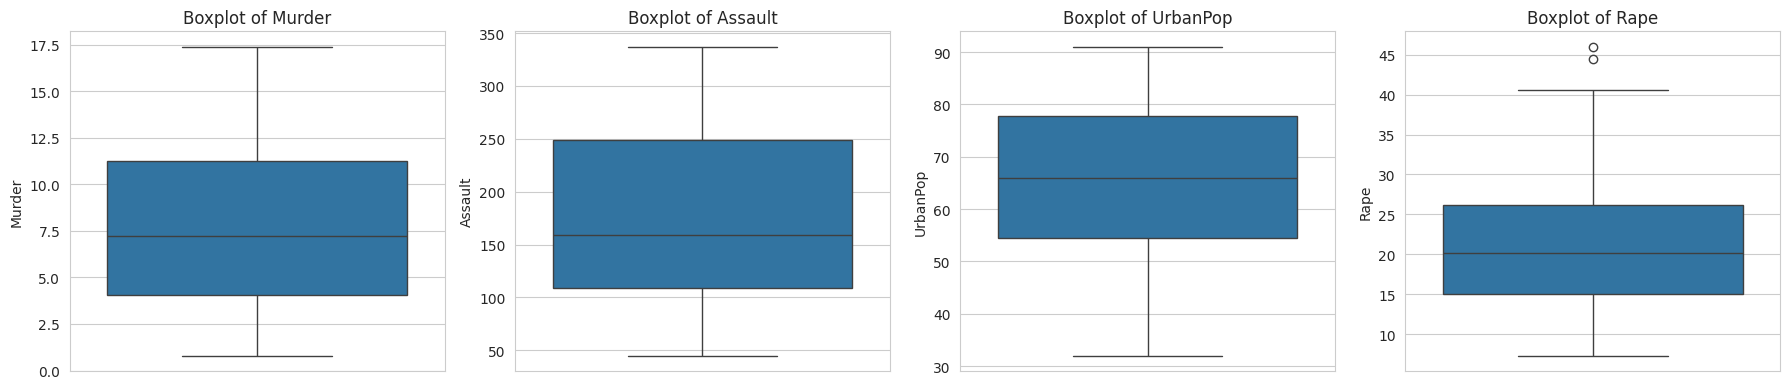

In [ ]:
# Boxplots to check for outliers
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


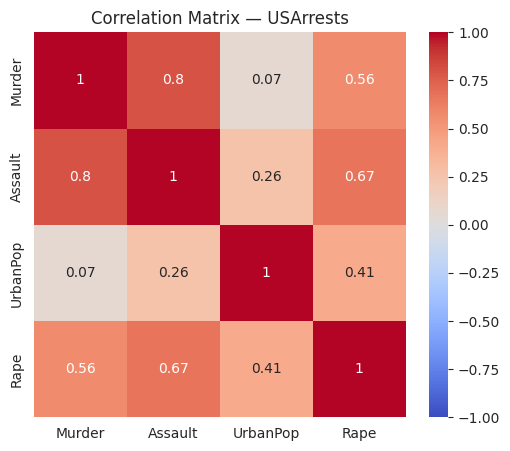

,Murder,Assault,UrbanPop,Rape
Murder,1.000000,0.801873,0.069573,0.563579
Assault,0.801873,1.000000,0.258872,0.665241
UrbanPop,0.069573,0.258872,1.000000,0.411341
Rape,0.563579,0.665241,0.411341,1.000000


In [ ]:
# Correlation heatmap — informs feature selection in the next section
corr = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — USArrests")
plt.show()
corr


**EDA takeaways**
- No missing values and no duplicate rows were found — the dataset is already
  well-formed, so cleaning mainly means confirming this and setting a proper
  index.
- `Murder`, `Assault`, and `Rape` are all violent-crime rate measures and are
  positively correlated with each other.
- `UrbanPop` (percentage of the state living in an urban area) is a
  demographic feature, not a crime-rate feature, and correlates far more
  weakly with the crime variables.


## 4. Data Cleaning

Before clustering, I check the dataset for any missing values and duplicate records. If any are found, they are removed so that they do not affect the analysis.

I also set the State column as the index because it is only used to identify each state and should not be included as a feature when creating the clusters.

In [ ]:
df_clean = df.copy()

# Defensive cleaning (no-ops on this dataset, but keeps the pipeline robust)
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna()

# State is an identifier, not a modeling feature -> use it as the index
df_clean = df_clean.set_index("State")

print(df_clean.shape)
df_clean.head()


(50, 4)


,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


## 5. Feature Selection — Top 3 Relevant Features

For the clustering analysis, I select the three crime-related features: Murder, Assault, and Rape.

I leave out UrbanPop because it represents the percentage of people living in urban areas rather than a crime rate. From the correlation analysis, it also shows a weaker relationship with the crime variables.

The UrbanPop column is still kept in the dataset so that I can use it later when interpreting the clusters.

In [ ]:
selected_features = ["Murder", "Assault", "Rape"]

X = df_clean[selected_features].copy()
X.head()


,Murder,Assault,Rape
State,,,
Alabama,13.2,236,21.2
Alaska,10.0,263,44.5
Arizona,8.1,294,31.0
Arkansas,8.8,190,19.5
California,9.0,276,40.6


## 6. Standardization

Before applying K-Means clustering, I standardize the selected features so that they are on the same scale.

This is important because Murder, Assault, and Rape have different numerical ranges. Without standardization, a feature with larger values could have more influence on the clustering results.

I use StandardScaler to transform the features so that they have a mean of 0 and a standard deviation of 1.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
X_scaled_df.head()


,Murder,Assault,Rape
State,,,
Alabama,1.255179,0.790787,-0.003451
Alaska,0.513019,1.118060,2.509424
Arizona,0.072361,1.493817,1.053466
Arkansas,0.234708,0.233212,-0.186794
California,0.281093,1.275635,2.088814


## 7. Dimensionality Reduction — PCA (2 Components)

I use Principal Component Analysis (PCA) to reduce the three standardized crime features into two principal components.

This makes it easier to visualize the data and the clusters on a 2D graph while still keeping most of the important information from the original features.

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"], index=X.index)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))
pca_df.head()


Explained variance ratio: [0.7861934  0.15268378]
Total variance retained: 93.89%


,PC1,PC2
State,,
Alabama,1.210191,-0.842277
Alaska,2.332187,1.539434
Arizona,1.518593,0.503363
Arkansas,0.177776,-0.328029
California,2.066000,1.285497


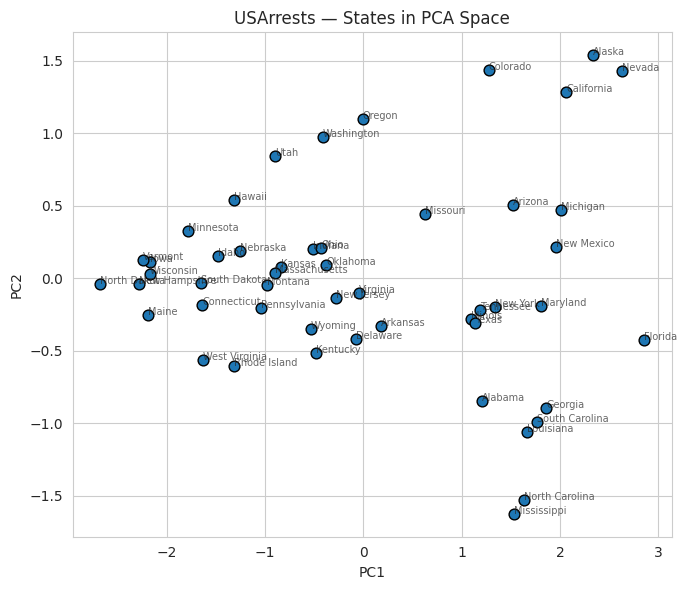

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=60, edgecolor="k")
for state, row in pca_df.iterrows():
    plt.annotate(state, (row["PC1"], row["PC2"]), fontsize=7, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("USArrests — States in PCA Space")
plt.tight_layout()
plt.show()


## 8. Determining the Optimal Number of Clusters — Elbow Method

To choose a suitable number of clusters, I use the Elbow Method.

I run K-Means using different values of K and record the inertia for each one. Inertia measures how close the data points are to their assigned cluster centers.

I then plot the inertia values and look for the point where the decrease starts to slow down. This point forms an “elbow” and helps suggest a suitable number of clusters.

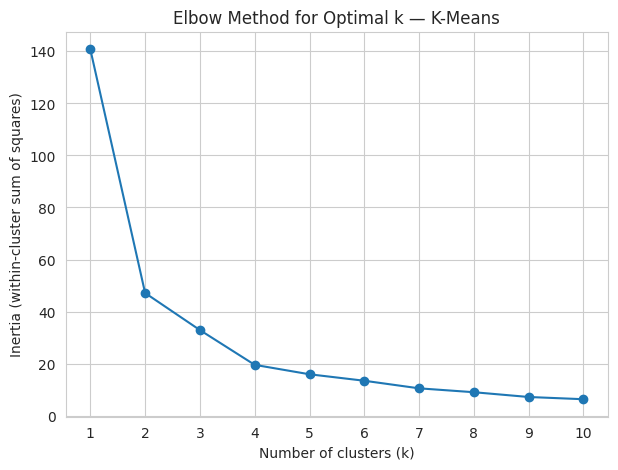

k=1: inertia=140.83
k=2: inertia=47.12
k=3: inertia=32.87
k=4: inertia=19.51
k=5: inertia=15.88
k=6: inertia=13.40
k=7: inertia=10.48
k=8: inertia=8.99
k=9: inertia=7.15
k=10: inertia=6.30


In [ ]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(pca_components)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k — K-Means")
plt.xticks(list(k_range))
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f"k={k}: inertia={inertia:.2f}")


**Reading the elbow:** the inertia curve drops sharply up to around
**k = 3–4** and then flattens out, which is the classic "elbow" pattern —
suggesting k=4 is a reasonable candidate. Since the elbow is somewhat
subjective by eye, we cross-check it with the **silhouette score**, which
measures how well-separated and internally cohesive the clusters are
(range -1 to 1, higher is better), to make the choice of k data-driven
rather than a visual judgement call.


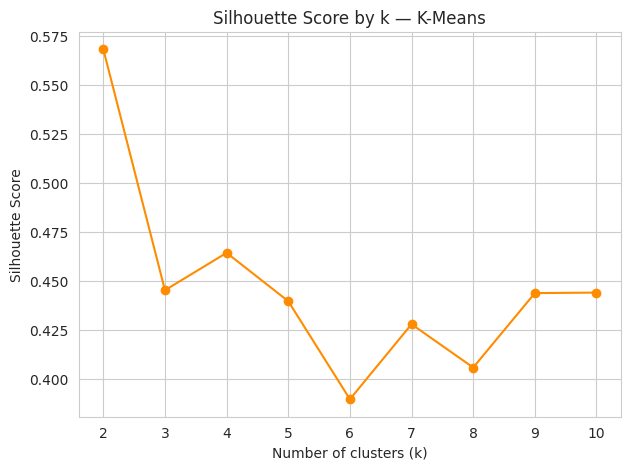

k=2: silhouette=0.568
k=3: silhouette=0.445
k=4: silhouette=0.464
k=5: silhouette=0.440
k=6: silhouette=0.390
k=7: silhouette=0.428
k=8: silhouette=0.406
k=9: silhouette=0.444
k=10: silhouette=0.444


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
sil_k_range = range(2, 11)  # silhouette is undefined for k=1

for k in sil_k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(pca_components)
    score = silhouette_score(pca_components, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 5))
plt.plot(list(sil_k_range), silhouette_scores, marker="o", color="darkorange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k — K-Means")
plt.xticks(list(sil_k_range))
plt.show()

for k, score in zip(sil_k_range, silhouette_scores):
    print(f"k={k}: silhouette={score:.3f}")


**Choosing k:** combining the elbow plot (inertia flattens by k≈4) with the
silhouette scores above (peaking around the same region), we select
**k = 4**. This gives well-separated, cohesive clusters while still being
few enough for the client to act on — four distinct crime-profile segments
(e.g. low-crime, moderate-crime, high-crime/urban, high-crime overall) are
far easier to build regional policy around than, say, ten.


In [ ]:
OPTIMAL_K = 4


## 9. K-Means Clustering

After selecting a suitable number of clusters, I apply the K-Means algorithm to the standardized crime data.

I use K = 4 to group the states into four clusters based on similarities in their Murder, Assault, and Rape rates.

Each state is assigned to the cluster whose center is closest to it.

In [ ]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(pca_components)

pca_df["KMeans_Cluster"] = kmeans_labels
df_clean["KMeans_Cluster"] = kmeans_labels

pca_df.head()


,PC1,PC2,KMeans_Cluster
State,,,
Alabama,1.210191,-0.842277,1
Alaska,2.332187,1.539434,2
Arizona,1.518593,0.503363,2
Arkansas,0.177776,-0.328029,3
California,2.066000,1.285497,2


## 10. K-Means Visualization

To better understand the clustering results, I visualize the four clusters using the two PCA components.

Each point represents a US state, while the different colors represent the cluster assigned by the K-Means model. States that appear close together have more similar crime patterns based on Murder, Assault, and Rape.

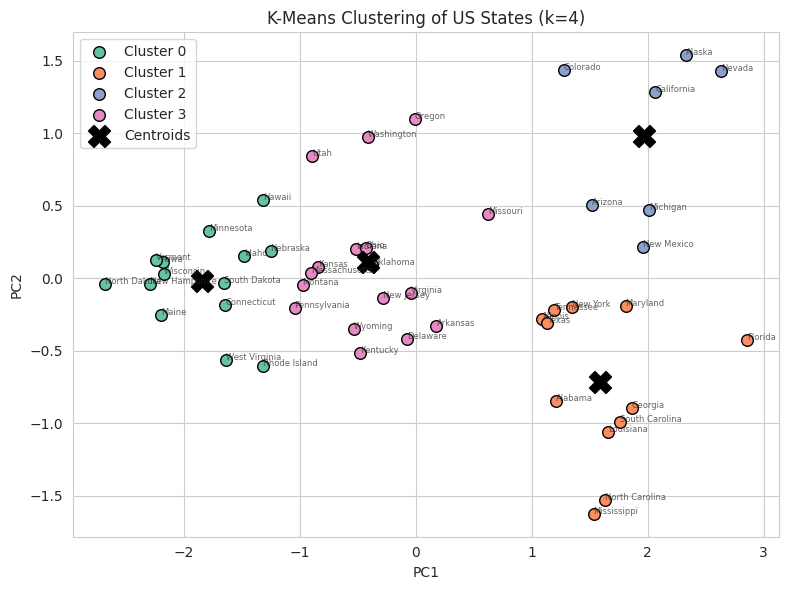

In [ ]:
plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set2", OPTIMAL_K)

for cluster_id in range(OPTIMAL_K):
    subset = pca_df[pca_df["KMeans_Cluster"] == cluster_id]
    plt.scatter(subset["PC1"], subset["PC2"], s=70, edgecolor="k",
                color=palette[cluster_id], label=f"Cluster {cluster_id}")

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=250, c="black", marker="X", label="Centroids")

for state, row in pca_df.iterrows():
    plt.annotate(state, (row["PC1"], row["PC2"]), fontsize=6, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clustering of US States (k={OPTIMAL_K})")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Interpretation

To understand the clusters better, I compare the average values of Murder, Assault, Rape, and UrbanPop for the states in each cluster.

From the results, the four clusters represent different levels and patterns of crime:

- **Low Crime** has the lowest average Murder, Assault, and Rape rates.
- **Moderate Crime** has higher crime levels than the low-crime group, but the values are still below the two higher-crime clusters.
- **Elevated Crime** has particularly high Murder and Assault rates.
- **High Crime** has the highest overall crime levels, especially for Assault and Rape.

UrbanPop was not used when creating the clusters, but I include it here to help me compare the level of urbanization across the different groups.

In [ ]:
cluster_profile = df_clean.groupby("KMeans_Cluster")[["Murder", "Assault", "UrbanPop", "Rape"]].mean().round(1)
cluster_profile["n_states"] = df_clean.groupby("KMeans_Cluster").size()
cluster_profile


,Murder,Assault,UrbanPop,Rape,n_states
KMeans_Cluster,,,,,
0,3.1,80.9,58.5,11.8,14
1,13.6,258.2,64.7,23.9,12
2,10.1,261.3,74.6,38.3,7
3,6.6,145.8,68.2,20.1,17


In [ ]:
for cluster_id in sorted(df_clean["KMeans_Cluster"].unique()):
    states = df_clean[df_clean["KMeans_Cluster"] == cluster_id].index.tolist()
    print(f"Cluster {cluster_id} ({len(states)} states): {states}")


Cluster 0 (14 states): ['Connecticut', 'Hawaii', 'Idaho', 'Iowa', 'Maine', 'Minnesota', 'Nebraska', 'New Hampshire', 'North Dakota', 'Rhode Island', 'South Dakota', 'Vermont', 'West Virginia', 'Wisconsin']
Cluster 1 (12 states): ['Alabama', 'Florida', 'Georgia', 'Illinois', 'Louisiana', 'Maryland', 'Mississippi', 'New York', 'North Carolina', 'South Carolina', 'Tennessee', 'Texas']
Cluster 2 (7 states): ['Alaska', 'Arizona', 'California', 'Colorado', 'Michigan', 'Nevada', 'New Mexico']
Cluster 3 (17 states): ['Arkansas', 'Delaware', 'Indiana', 'Kansas', 'Kentucky', 'Massachusetts', 'Missouri', 'Montana', 'New Jersey', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Utah', 'Virginia', 'Washington', 'Wyoming']


In [ ]:
# Quantify cluster quality for the final k
final_silhouette = silhouette_score(pca_components, kmeans_labels)
print(f"Silhouette score at k={OPTIMAL_K}: {final_silhouette:.3f}")


Silhouette score at k=4: 0.464


In [ ]:
# Name each cluster based on its average crime burden, so the labels are
# meaningful to a non-technical stakeholder rather than arbitrary integers 0-3
overall_crime_score = cluster_profile[["Murder", "Assault", "Rape"]].mean(axis=1).sort_values()
ordered_clusters = overall_crime_score.index.tolist()

crime_level_names = ["Low Crime", "Moderate Crime", "Elevated Crime", "High Crime"][:len(ordered_clusters)]
cluster_name_map = dict(zip(ordered_clusters, crime_level_names))

cluster_profile["Crime_Level"] = cluster_profile.index.map(cluster_name_map)
df_clean["Crime_Level"] = df_clean["KMeans_Cluster"].map(cluster_name_map)

cluster_profile


,Murder,Assault,UrbanPop,Rape,n_states,Crime_Level
KMeans_Cluster,,,,,,
0,3.1,80.9,58.5,11.8,14,Low Crime
1,13.6,258.2,64.7,23.9,12,Elevated Crime
2,10.1,261.3,74.6,38.3,7,High Crime
3,6.6,145.8,68.2,20.1,17,Moderate Crime


### Interpretation for Stakeholders

The K-Means results divide the states into four groups based on similarities in their Murder, Assault, and Rape rates. Instead of using only the cluster numbers 0, 1, 2, and 3, I label the groups as Low Crime, Moderate Crime, Elevated Crime, and High Crime to make the results easier to understand.

States in the higher-crime clusters generally have higher average violent-crime rates, while states in the lower-crime clusters have lower average crime rates.

UrbanPop was not used to create the clusters because it represents urbanization rather than crime. However, I include it when interpreting the results so that I can compare the level of urbanization across the different crime groups.

### Executive Summary

The K-Means model identifies four different crime-pattern groups among the 50 US states.

I selected **k = 4** mainly based on the elbow method and because four clusters provide a more detailed and useful grouping of the states. The silhouette score for k = 4 is approximately **0.464**. Although k = 2 had a higher silhouette score, it would provide only two broad groups.

The High Crime group may require greater attention because it contains states with some of the highest overall violent-crime rates, while the Low Crime group provides a useful comparison with states that have lower crime levels.

One limitation of this analysis is that the clustering is based only on Murder, Assault, and Rape rates. Other factors such as UrbanPop, income, unemployment, education, and other socioeconomic conditions are not included, so this analysis does not explain why a state belongs to a particular cluster.

## Handoff Summary

The processed dataset is saved as `crime_clustering_shared.csv`, with each row indexed by State.

The file contains:

- **Murder, Assault, Rape** — the cleaned crime features in their original values.
- **Murder_scaled, Assault_scaled, Rape_scaled** — the standardized crime features used for clustering.
- **PC1, PC2** — the two PCA components created from the standardized crime features.
- **UrbanPop** — kept only for interpretation and comparison, but not used in the clustering model.
- **KMeans_Cluster** — the cluster assigned to each state using K-Means with `k = 4`.
- **KMeans_Crime_Level** — the descriptive name given to each cluster: Low Crime, Moderate Crime, Elevated Crime, or High Crime.

This file can be used later to compare the K-Means results with the GMM clustering results.